# BrushCue Example: Y2K Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/y2k_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/y2k-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


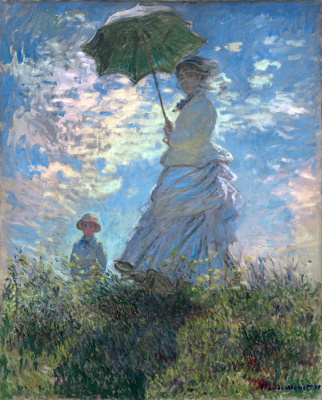

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
chromed = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet pop = max(band(h, -0.15, 1.0), band(h, 4.15, 0.9)) * colorful;\nlet skin = band(h, 0.9, 0.6) * colorful;\nlet c2 = c * mix(1.0, mix(0.8, 1.25, pop), amount);\nlet hi = smoothstep(0.65, 1.0, input.x);\nlet gloss = input.x * input.x * (3.0 - 2.0 * input.x);\nlet l = mix(input.x, gloss, 0.3 * amount) + 0.05 * hi * amount;\nlet cool = (1.0 - 0.7 * skin) * amount;\nlet a = c2 * cos(h) - 0.004 * cool;\nlet b = c2 * sin(h) - (0.014 + 0.01 * hi) * cool;\nlet rolloff = 1.0 - smoothstep(0.92, 1.05, l);\nreturn vec4<f32>(clamp(l, 0.0, 1.0), a * rolloff, b * rolloff, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
bounds = input_image.bounds()
iridescent = chromed.spacial_effect_shader(
    "let col = sample(position);\nlet uv = (position - origin) / size;\nlet chroma = length(col.yz);\nlet neutral = 1.0 - smoothstep(0.02, 0.07, chroma);\nlet skin = band(atan2(col.z, col.y), 0.9, 0.7) * smoothstep(0.008, 0.025, chroma);\nlet hi = smoothstep(0.62, 0.95, col.x) * neutral * (1.0 - skin);\nlet phase = (uv.x * 0.8 + uv.y) * 9.0 + col.x * 10.0;\nlet sheen = vec2<f32>(cos(phase), sin(phase)) * 0.05 * hi * amount;\nreturn vec4<f32>(col.x, col.y + sheen.x, col.z + sheen.y, col.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    0.0,
    bc.Dictionary.create()
    .add("amount", strength)
    .add("origin", bc.Vector2f.from_components(bounds.min_x(), bounds.min_y()))
    .add("size", bc.Vector2f.from_components(bounds.width(), bounds.height())),
    bc.ColorRepresentation.oklab_a(),
)
crisp = iridescent.sharpen(1.2, (0.6 * strength))
glinted = crisp.bloom(0.82, (bounds.width() * 0.004), (0.3 * strength))
graph = glinted.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
